# Consumo de eletricidade na China: análise descritiva e periodicidade
**Econometria II · janeiro de 2015 a dezembro de 2024**

## 1. Definição da série e confirmação da fonte
**Série escolhida:** consumo mensal de eletricidade de toda a sociedade chinesa, indicador **全社会用电量** (*whole-society electricity consumption*), divulgado pela **National Energy Administration — NEA (国家能源局)**. Abrange os três setores econômicos e o consumo residencial urbano e rural. Mantém-se o agregado nacional conforme a cobertura publicada pela fonte.

**A NEA é uma fonte oficial apropriada para este indicador**, com boletins mensais e anuais. Seu arquivo, porém, está distribuído em páginas HTML; esta base foi organizada a partir dessas publicações, e não obtida como uma tabela histórica única já harmonizada. Há uma URL e um trecho original para cada valor extraído, além das páginas arquivadas com hash SHA-256.

**Recorte conceitual importante:** aqui, “energia” significa **eletricidade consumida**. O consumo total de energia, incluindo carvão, petróleo e gás, é outro indicador: o **National Bureau of Statistics — NBS** publica esse agregado em equivalente de carvão padrão. A eletricidade mensal é mais conveniente para estudar sazonalidade, médias móveis e suavização dentro do intervalo de dez anos proposto. Não confundir consumo com geração de eletricidade, potência instalada ou taxa de crescimento.

| Item | Definição |
|---|---|
| Indicador original | 全社会用电量 |
| Variável de análise | Volume de eletricidade consumido no mês |
| Unidade original | 亿千瓦时: 100 milhões de kWh |
| Unidade utilizada | TWh: 1 trilhão de Wh = 1 bilhão de kWh |
| Conversão | Valor original ÷ 10 = TWh |
| Frequência | Mensal; mês de referência, não mês da publicação |
| Grade temporal | 120 meses: 2015-01 a 2024-12 |
| Natureza | Quantitativa contínua, agregada e arredondada; variável de fluxo |
| Data desta coleta | 10/09/2026 |

**Fontes consultadas:**
- [Arquivo de boletins da NEA](https://www.nea.gov.cn/sjzz/ghs/zjgx.htm).
- [NEA: consumo de março de 2024](https://www.nea.gov.cn/2024-04/17/c_1310771602.htm), exemplo de divulgação mensal e acumulada.
- [NEA: janeiro–fevereiro de 2024](https://www.nea.gov.cn/2024-03/20/c_1310768302.htm), com apenas o total do bimestre.
- [NEA: total anual de 2024](https://www.nea.gov.cn/20250120/4f7f249bac714e7693adecac996d742f/c.html).
- [NBS: comunicado estatístico de 2024](https://www.stats.gov.cn/english/PressRelease/202502/t20250228_1958822.html), seção de consumo total de energia.

**Nota de procedência:** maio de 2023 foi obtido em [republicação do People's Daily no portal de cooperação energética da NEA](https://obor.nea.gov.cn/detail/19346.html), que atribui os números à NEA. Essa observação é identificada no CSV; não se apresenta a republicação como boletim original.

## 2. Reprodutibilidade
O notebook acompanha a pasta `dados/energia_china` e os scripts `coletar_energia_china.py` e `preparar_energia_china.py`. Execute a partir do diretório do notebook. As saídas já estão incorporadas.

Dependências: Python, pandas, numpy, matplotlib e IPython. O coletor utiliza `curl`, mantendo a verificação de certificados. Por padrão, a execução usa as páginas locais arquivadas; o download pode ser refeito quando necessário. Os arquivos originais em cache não são sobrescritos automaticamente.

In [1]:
from pathlib import Path
import sys
import subprocess
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RAIZ = Path.cwd()
BASE = RAIZ / "dados/energia_china"
FIGURAS = RAIZ / "figuras"
FIGURAS.mkdir(exist_ok=True)
plt.rcParams.update({"figure.figsize": (12, 4.5), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

# True consulta o arquivo de boletins e baixa as páginas ainda não presentes no cache.
BAIXAR_FONTES = False
if BAIXAR_FONTES or not (BASE / "manifesto_fontes.json").exists():
    processo = subprocess.run([sys.executable, "coletar_energia_china.py"],
                              cwd=RAIZ, capture_output=True, text=True, check=True)
    print(processo.stdout)

manifesto = json.loads((BASE / "manifesto_fontes.json").read_text())
for fonte in manifesto:
    arquivo = BASE / fonte["arquivo"]
    assert arquivo.exists(), f"Página ausente: {arquivo}"
    assert hashlib.sha256(arquivo.read_bytes()).hexdigest() == fonte["sha256"], arquivo
print(f"{len(manifesto)} páginas de referência arquivadas e hashes conferidos.")
print("Primeira coleta UTC registrada:", min(f["coleta_utc"] for f in manifesto))
print("Indicador: consumo de eletricidade; unidade da análise: TWh.")

112 páginas de referência arquivadas e hashes conferidos.
Primeira coleta UTC registrada: 2026-09-10T16:43:02.224878+00:00
Indicador: consumo de eletricidade; unidade da análise: TWh.


## 3. Extração, reconstituição e lacunas
O script extrai os valores explicitamente apresentados como mensais, acumulados e anuais, mantendo essas categorias separadas. Os números são vinculados ao mês de referência; por exemplo, um boletim de março geralmente informa fevereiro.

**Janeiro de 2015–2023:** quando o mesmo boletim publica fevereiro e o acumulado janeiro–fevereiro, janeiro é reconstituído por:


$$C_{jan}=C_{jan+fev}-C_{fev}.$$

Essa é uma identidade contábil aplicada aos números arredondados da mesma publicação, **não uma imputação estatística**. A coluna `observado_direto_twh` continua vazia nesses nove meses, e `status` registra sua origem.

**Lacunas preservadas:** não foram localizados valores mensais separados para dezembro de 2015–2024 nos boletins coletados, nem a divisão janeiro/fevereiro de 2024. O total deste último bimestre é conhecido: **1.531,6 TWh**. Isso não significa consumo zero nem prova que esses valores não existam em outros arquivos. Não dividimos o bimestre por dois.

Também não atribuímos automaticamente a dezembro a diferença entre o total anual e o acumulado até novembro, pois são divulgações distintas e podem conter revisões. A seção de consistência mostra divergências efetivas entre acumulados e a soma dos meses.

`valor_twh` combina **99 observações diretas e 9 reconstituições da mesma fonte**. Os 12 meses restantes são mantidos como `NaN`. Não há suavização, imputação por modelo ou exclusão de outliers nesta etapa.

In [2]:
# Regenera a tabela a partir das páginas arquivadas, sem acesso à rede.
processo = subprocess.run([sys.executable, "preparar_energia_china.py"],
                          cwd=RAIZ, capture_output=True, text=True, check=True)
print(processo.stdout)
dados = pd.read_csv(BASE / "consumo_eletricidade_china_mensal.csv",
                    parse_dates=["data", "publicacao"])
extraidos = pd.read_csv(BASE / "valores_extraidos.csv")
serie = dados.set_index("data")["valor_twh"].asfreq("MS")
colunas = ["data", "valor_twh", "observado_direto_twh", "status", "url"]
display(dados[colunas].head(14))

,data,valor_twh,observado_direto_twh,status,url
0,2015-01-01,485.9,NaN,reconstituido_mesma_fonte,https://www.nea.gov.cn/2015-03/16/c_134070233.htm
1,2015-02-01,359.5,359.5,observado_mensal,https://www.nea.gov.cn/2015-03/16/c_134070233.htm
2,2015-03-01,444.8,444.8,observado_mensal,https://www.nea.gov.cn/2015-04/16/c_134155763.htm
3,2015-04-01,441.5,441.5,observado_mensal,https://www.nea.gov.cn/2015-05/14/c_134239299.htm
4,2015-05-01,456.7,456.7,observado_mensal,https://www.nea.gov.cn/2015-06/15/c_134328029.htm
5,2015-06-01,472.3,472.3,observado_mensal,https://www.nea.gov.cn/2015-07/15/c_134414315.htm
6,2015-07-01,503.4,503.4,observado_mensal,https://www.nea.gov.cn/2015-08/14/c_134517626.htm
7,2015-08-01,512.4,512.4,observado_mensal,https://www.nea.gov.cn/2015-09/15/c_134625502.htm
8,2015-09-01,456.3,456.3,observado_mensal,https://www.nea.gov.cn/2015-10/19/c_134727170.htm
9,2015-10-01,449.1,449.1,observado_mensal,https://www.nea.gov.cn/2015-11/16/c_134821470.htm


Valores extraídos por tipo: {'acumulado': 100, 'mensal': 99, 'anual': 10}
Meses ausentes: ['2015-12', '2016-12', '2017-12', '2018-12', '2019-12', '2020-12', '2021-12', '2022-12', '2023-12', '2024-01', '2024-02', '2024-12']
      count    min    max
data                     
2015     11  359.5  512.4
2016     11  381.2  563.1
2017     11  448.8  607.2
2018     11  455.7  652.1
2019     11  489.1  677.0
2020     11  439.8  729.4
2021     11  526.4  775.8
2022     11  623.5  852.0
2023     11  688.4  888.8
2024      9  741.2  964.9



In [3]:
grade = pd.date_range("2015-01-01", "2024-12-01", freq="MS")
assert len(dados) == 120
assert dados["data"].is_unique
assert serie.index.equals(grade)
assert dados["data"].dt.day.eq(1).all()
assert (serie.dropna() > 0).all()
assert np.allclose(dados["valor_twh"].dropna(),
                   dados.loc[dados["valor_twh"].notna(), "valor_100_milhoes_kwh"] / 10)
assert dados.loc[dados.valor_twh.notna(), "url"].notna().all()
assert (dados.loc[dados.valor_twh.notna(), "publicacao"] >
        dados.loc[dados.valor_twh.notna(), "data"]).all()

integridade = pd.Series({
    "Meses no calendário": len(serie),
    "Valores mensais diretos": dados["observado_direto_twh"].count(),
    "Reconstituições na mesma fonte": dados["status"].eq("reconstituido_mesma_fonte").sum(),
    "Valores disponíveis para análise": serie.count(),
    "Lacunas preservadas": serie.isna().sum(),
    "Lacunas (%)": 100 * serie.isna().mean(),
    "Datas duplicadas": dados["data"].duplicated().sum()
}, name="Resultado")
display(integridade.to_frame())
display(dados.loc[serie.isna().to_numpy(), ["data", "status", "nota"]])
print("Meses com valores: de", serie.first_valid_index().strftime("%Y-%m"),
      "até", serie.last_valid_index().strftime("%Y-%m"))

,Resultado
Meses no calendário,120.0
Valores mensais diretos,99.0
Reconstituições na mesma fonte,9.0
Valores disponíveis para análise,108.0
Lacunas preservadas,12.0
Lacunas (%),10.0
Datas duplicadas,0.0


,data,status,nota
11,2015-12-01,nao_localizado_mensal,Valor mensal não localizado nos boletins colet...
23,2016-12-01,nao_localizado_mensal,Valor mensal não localizado nos boletins colet...
35,2017-12-01,nao_localizado_mensal,Valor mensal não localizado nos boletins colet...
47,2018-12-01,nao_localizado_mensal,Valor mensal não localizado nos boletins colet...
59,2019-12-01,nao_localizado_mensal,Valor mensal não localizado nos boletins colet...
71,2020-12-01,nao_localizado_mensal,Valor mensal não localizado nos boletins colet...
83,2021-12-01,nao_localizado_mensal,Valor mensal não localizado nos boletins colet...
95,2022-12-01,nao_localizado_mensal,Valor mensal não localizado nos boletins colet...
107,2023-12-01,nao_localizado_mensal,Valor mensal não localizado nos boletins colet...
108,2024-01-01,nao_localizado_mensal,Boletim divulga apenas janeiro–fevereiro: 1531...


Meses com valores: de 2015-01 até 2024-11


## 4. Estatística descritiva
As estatísticas principais usam os **108 valores disponíveis**, incluindo os nove janeiros reconstituídos. Portanto, **não são estatísticas de 120 meses completos**. A ausência sistemática de dezembro e a falta de janeiro/fevereiro de 2024 podem alterar as medidas e a comparação entre anos.

O desvio-padrão e a variância são amostrais (`ddof=1`). O coeficiente de variação é $100s/\bar{x}$. A curtose é apresentada como excesso de curtose, cuja referência normal é zero. Como há tendência e dependência temporal, o desvio-padrão não deve ser interpretado como volatilidade de uma série estacionária.

A segunda coluna mostra apenas as 99 observações diretamente publicadas, para explicitar o efeito da composição da amostra.

In [4]:
def descrever(s):
    x = s.dropna()
    return pd.Series({
        "Observações": len(x),
        "Soma dos meses disponíveis (TWh)": x.sum(),
        "Média (TWh/mês)": x.mean(),
        "Mediana (TWh/mês)": x.median(),
        "Mínimo (TWh)": x.min(),
        "1º quartil (TWh)": x.quantile(.25),
        "3º quartil (TWh)": x.quantile(.75),
        "Máximo (TWh)": x.max(),
        "Amplitude (TWh)": x.max() - x.min(),
        "Amplitude interquartil (TWh)": x.quantile(.75) - x.quantile(.25),
        "Variância amostral (TWh²)": x.var(ddof=1),
        "Desvio-padrão amostral (TWh)": x.std(ddof=1),
        "Coeficiente de variação (%)": 100*x.std(ddof=1)/x.mean(),
        "Assimetria": x.skew(),
        "Excesso de curtose": x.kurt()
    })
resumo = pd.concat({"Disponíveis (108)": descrever(serie),
                    "Somente diretos (99)": descrever(dados["observado_direto_twh"])}, axis=1)
display(resumo.round(3))
print(f"Mínimo disponível: {serie.min():.1f} TWh em {serie.idxmin():%m/%Y}.")
print(f"Máximo disponível: {serie.max():.1f} TWh em {serie.idxmax():%m/%Y}.")
print(f"Média: {serie.mean():.2f} TWh/mês; mediana: {serie.median():.2f} TWh/mês.")
print("A soma disponível não é o consumo total da década, pois existem lacunas.")

,Disponíveis (108),Somente diretos (99)
Observações,108.000,99.000
Soma dos meses disponíveis (TWh),66736.100,61327.200
Média (TWh/mês),617.927,619.467
Mediana (TWh/mês),600.750,602.000
Mínimo (TWh),359.500,359.500
1º quartil (TWh),512.850,513.450
3º quartil (TWh),697.075,699.150
Máximo (TWh),964.900,964.900
Amplitude (TWh),605.400,605.400
Amplitude interquartil (TWh),184.225,185.700


Mínimo disponível: 359.5 TWh em 02/2015.
Máximo disponível: 964.9 TWh em 08/2024.
Média: 617.93 TWh/mês; mediana: 600.75 TWh/mês.
A soma disponível não é o consumo total da década, pois existem lacunas.


### Resumo anual e comparação das publicações
Os totais anuais abaixo vêm dos **boletins anuais da NEA**, independentemente da disponibilidade dos meses. A soma parcial dos meses observados é apresentada em outra coluna e não é chamada de total anual. A média mensal do ano completo pode ser calculada como total anual/12, mesmo quando a divisão mensal está incompleta.

As diferenças entre a soma janeiro–novembro e o acumulado oficialmente publicado até novembro são uma verificação de consistência entre versões das publicações. Podem refletir revisões ou arredondamentos; não são corrigidas arbitrariamente.

In [5]:
anuais = (extraidos[extraidos["tipo"].eq("anual")]
          .set_index("ano")["valor_twh"].sort_index())
assert anuais.index.is_unique and len(anuais) == 10
anual = serie.groupby(serie.index.year).agg(
    meses_disponiveis="count", soma_parcial_twh="sum",
    media_disponivel_twh="mean", mediana_twh="median", desvio_padrao_twh="std")
anual["total_anual_oficial_twh"] = anuais
anual["media_ano_completo_twh"] = anuais / 12
anual.index.name = "Ano"
display(anual.round(2))

acum11 = (extraidos[extraidos.tipo.eq("acumulado") & extraidos.mes.eq(11)]
          .set_index("ano")["valor_twh"].sort_index())
jan_nov = serie[serie.index.month <= 11]
somas11 = jan_nov.groupby(jan_nov.index.year).sum(min_count=11)
consistencia = pd.concat({"Soma de 11 meses (TWh)": somas11,
                         "Acumulado NEA até novembro (TWh)": acum11}, axis=1)
consistencia["Diferença (TWh)"] = somas11 - acum11
display(consistencia.round(2))
print("NaN em 2024: janeiro e fevereiro não estão separados; não se soma uma série incompleta.")

,meses_disponiveis,soma_parcial_twh,media_disponivel_twh,mediana_twh,desvio_padrao_twh,total_anual_oficial_twh,media_ano_completo_twh
Ano,,,,,,,
2015,11,5047.7,458.88,456.7,40.36,5550.0,462.50
2016,11,5382.9,489.35,492.5,47.96,5919.8,493.32
2017,11,5737.4,521.58,513.9,47.07,6307.7,525.64
2018,11,6216.6,565.15,564.7,55.78,6844.9,570.41
2019,11,6514.5,592.23,591.2,51.88,7225.5,602.12
2020,11,6675.5,606.86,617.2,76.99,7511.0,625.92
2021,11,7497.0,681.55,672.4,67.44,8312.8,692.73
2022,11,7853.8,713.98,694.4,72.44,8637.2,719.77
2023,11,8368.6,760.78,741.9,70.49,9224.1,768.68


,Soma de 11 meses (TWh),Acumulado NEA até novembro (TWh),Diferença (TWh)
2015,5047.7,5049.3,-1.6
2016,5382.9,5384.7,-1.8
2017,5737.4,5733.1,4.3
2018,6216.6,6219.9,-3.3
2019,6514.5,6514.4,0.1
2020,6675.5,6677.2,-1.7
2021,7497.0,7497.2,-0.2
2022,7853.8,7858.8,-5.0
2023,8368.6,8367.8,0.8
2024,NaN,8968.6,NaN


NaN em 2024: janeiro e fevereiro não estão separados; não se soma uma série incompleta.


## 5. Gráficos da série
O primeiro painel mostra os valores mensais disponíveis. **A linha é interrompida nas lacunas**; as marcações vermelhas na base assinalam os meses sem valor separado. Os círculos vazados identificam os janeiros reconstituídos. Não se traça uma interpolação disfarçada entre os meses ausentes.

O segundo painel utiliza os totais anuais oficiais, cuja cobertura é completa para os dez anos, permitindo visualizar a evolução agregada.

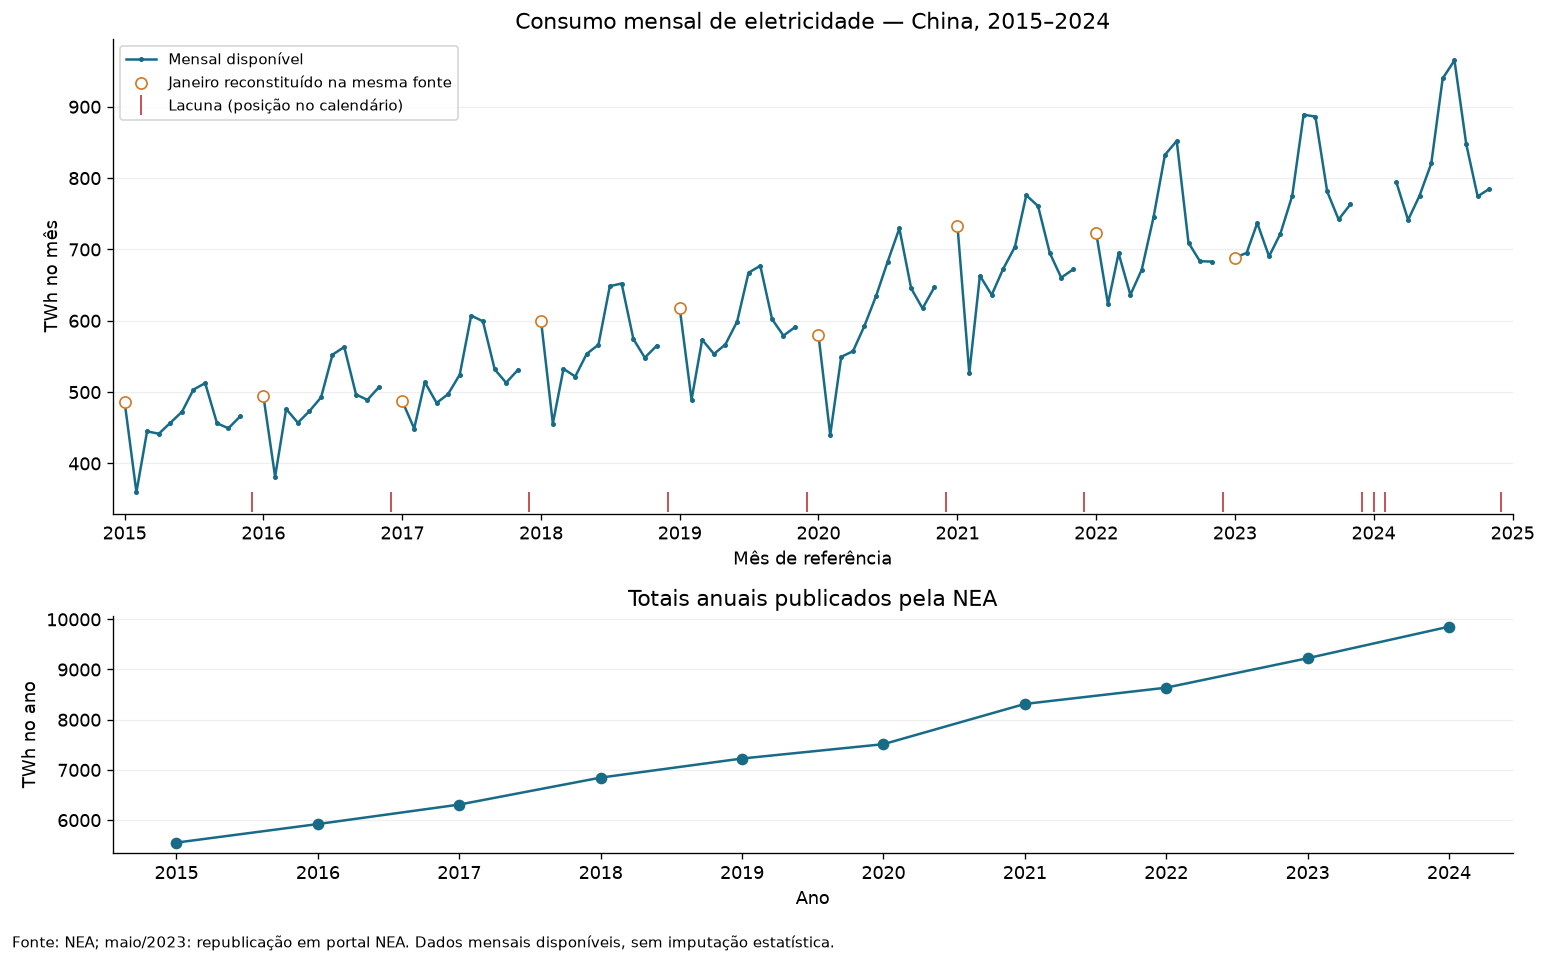

In [6]:
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(13, 8), gridspec_kw={"height_ratios": [2, 1]})
ax.plot(serie.index, serie, color="#176B87", linewidth=1.5,
        marker=".", markersize=4, label="Mensal disponível")
rec = dados[dados.status.eq("reconstituido_mesma_fonte")]
ax.scatter(rec.data, rec.valor_twh, s=45, facecolors="white", edgecolors="#D17820",
           zorder=4, label="Janeiro reconstituído na mesma fonte")
faltas = serie.index[serie.isna()]
ax.plot(faltas, np.full(len(faltas), .025), "|", color="#BA3636", markersize=12,
        transform=ax.get_xaxis_transform(), label="Lacuna (posição no calendário)")
ax.set(title="Consumo mensal de eletricidade — China, 2015–2024",
       ylabel="TWh no mês", xlabel="Mês de referência")
ax.set_xlim(pd.Timestamp("2014-12-01"), pd.Timestamp("2025-01-01"))
ax.grid(axis="y", alpha=.2)
ax.legend(loc="upper left", fontsize=9)
ax2.plot(anuais.index, anuais.values, color="#176B87", marker="o")
ax2.set(title="Totais anuais publicados pela NEA", xlabel="Ano", ylabel="TWh no ano")
ax2.set_xticks(anuais.index)
ax2.grid(axis="y", alpha=.2)
fig.text(.01, .005, "Fonte: NEA; maio/2023: republicação em portal NEA. Dados mensais disponíveis, sem imputação estatística.", fontsize=9)
fig.tight_layout(rect=(0, .025, 1, 1))
fig.savefig(FIGURAS / "energia_china_serie_temporal.png", dpi=160, bbox_inches="tight")
plt.show()

## 6. Periodicidade e sazonalidade
**Classificação:** série temporal univariada, com **frequência mensal em calendário regular**, mas com lacunas de valores. Cada observação representa o fluxo de eletricidade consumido durante um mês. Meses têm durações diferentes; regularidade mensal não significa intervalos de 30 dias.

**Sazonalidade:** procuramos uma repetição aproximada a cada **12 meses**. Para reduzir a influência do crescimento do nível entre anos, calculamos:


$$I_{a,m}=\frac{C_{a,m}}{A_a/12},$$

em que $A_a$ é o total anual oficial. O índice compara cada mês à média mensal do respectivo ano completo; por exemplo, 1,10 significa 10% acima dessa média. Trata-se de um perfil exploratório, não de uma decomposição sazonal formal.

A normalização usa o total do ano inteiro e, portanto, serve para **análise retrospectiva**, não para previsão em tempo real. Também mostramos a média diária ($C_{a,m}$/dias do mês) para avaliar o efeito de meses com durações diferentes.

Dezembro não possui observações mensais separadas nesta coleta; logo, o perfil sazonal desse mês não é estimado. Janeiro e fevereiro têm nove observações cada; março–novembro têm dez.

,Índice médio,Índice mediano,Observações
Mês,,,
1,0.993,1.005,9
2,0.805,0.799,9
3,0.952,0.960,10
4,0.913,0.916,10
5,0.954,0.946,10
6,1.008,1.004,10
7,1.128,1.128,10
8,1.143,1.142,10
9,1.008,1.007,10


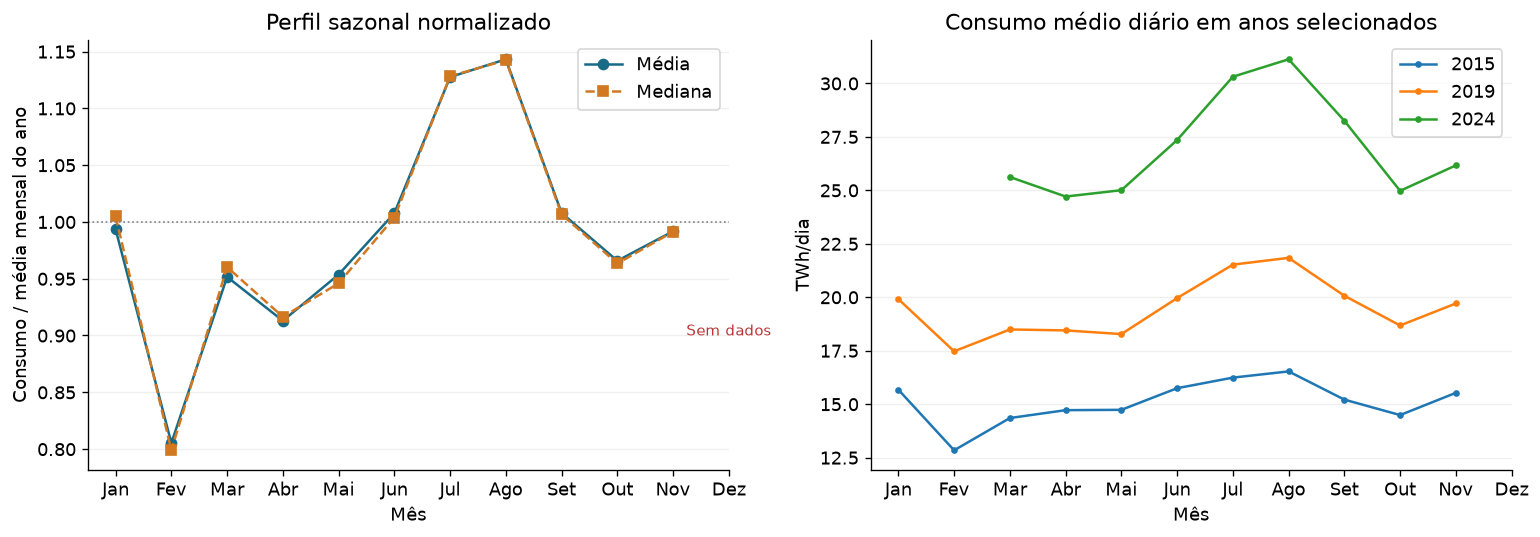

,Série,Defasagem (meses),Pares válidos,Correlação
0,Nível mensal,1,98,0.875
1,Nível mensal,12,97,0.967
2,Índice normalizado por ano,1,98,0.419
3,Índice normalizado por ano,12,97,0.900


In [7]:
medias_anuais = pd.Series(serie.index.year, index=serie.index).map(anuais / 12)
indice = serie / medias_anuais
perfil = indice.groupby(indice.index.month).agg(["mean", "median", "count"]).reindex(range(1,13))
nomes = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
perfil.index.name = "Mês"
display(perfil.rename(columns={"mean": "Índice médio", "median": "Índice mediano",
                               "count": "Observações"}).round(3))

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))
ax.plot(perfil.index, perfil["mean"], "o-", color="#176B87", label="Média")
ax.plot(perfil.index, perfil["median"], "s--", color="#D17820", label="Mediana")
ax.axhline(1, color="gray", linewidth=1, linestyle=":")
ax.set(title="Perfil sazonal normalizado", ylabel="Consumo / média mensal do ano",
       xlabel="Mês", xticks=range(1,13), xticklabels=nomes)
ax.text(12, .9, "Sem dados", ha="center", color="#BA3636", fontsize=9)
ax.legend()
ax.grid(axis="y", alpha=.2)

por_dia = serie / serie.index.days_in_month
for ano in [2015, 2019, 2024]:
    selecao = por_dia[por_dia.index.year == ano]
    ax2.plot(selecao.index.month, selecao, marker=".", label=str(ano))
ax2.set(title="Consumo médio diário em anos selecionados", ylabel="TWh/dia",
        xlabel="Mês", xticks=range(1,13), xticklabels=nomes)
ax2.legend()
ax2.grid(axis="y", alpha=.2)
fig.tight_layout()
fig.savefig(FIGURAS / "energia_china_sazonalidade.png", dpi=160, bbox_inches="tight")
plt.show()

# Mantém o calendário: retirar NaN antes do shift alteraria o sentido da defasagem!
def correlacao_calendario(s, lag):
    pares = pd.concat([s.rename("atual"), s.shift(lag).rename("defasado")], axis=1).dropna()
    return len(pares), pares["atual"].corr(pares["defasado"])
linhas = []
for nome, s in [("Nível mensal", serie), ("Índice normalizado por ano", indice)]:
    for lag in [1, 12]:
        n, corr = correlacao_calendario(s, lag)
        linhas.append([nome, lag, n, corr])
autocorrelacao = pd.DataFrame(linhas, columns=["Série", "Defasagem (meses)", "Pares válidos", "Correlação"])
display(autocorrelacao.round(3))

### Interpretação
O gráfico mensal e o perfil normalizado mostram **picos recorrentes em julho e agosto**, enquanto fevereiro apresenta nível relativamente baixo. Isso sustenta uma **sazonalidade anual aproximada, com período de 12 meses**, nos meses observados. O consumo anual também cresce ao longo do recorte, indicando mudança de nível/tendência.

A correlação com a defasagem de 12 meses no nível bruto é alta, mas parte pode refletir a tendência. A comparação do índice normalizado por ano oferece um diagnóstico adicional. Essas correlações são calculadas apenas nos pares disponíveis e **não são testes formais de sazonalidade ou estacionariedade**.

Temperatura, atividade econômica, número de dias e feriados móveis são fatores a investigar, sem atribuição causal nesta análise. A própria [NEA discute efeitos de temperatura e ano bissexto sobre o consumo](https://www.nea.gov.cn/xwfb/202504zb/iframe_text.htm). Não devemos classificar uma queda em fevereiro ou um pico de verão automaticamente como erro.

## 7. Adequação à atividade de Econometria II
**Conclusão: a série é adequada, com cuidados de preparação claramente identificados.** O recorte contém dez anos de calendário e 108 valores mensais disponíveis, suficientes para uma atividade descritiva e para experimentar os métodos propostos. A divulgação em boletins exige mais trabalho de organização que uma base pronta.

| Exigência | Como utilizar esta série |
|---|---|
| Identificação de outliers | Avaliar desvios após considerar tendência, sazonalidade e calendário; um boxplot global mistura níveis de anos diferentes. |
| Tratamento de outliers | Investigar a fonte e o contexto; preservar picos econômicos reais. Comparar tratamentos somente quando houver justificativa. |
| Dados faltantes | Manter a máscara das 12 lacunas. Comparar imputações em valores conhecidos ocultados artificialmente e avaliar MAE/RMSE; não há valor verdadeiro mensal de referência para as lacunas originais nesta coleta. |
| Informação agregada | Janeiro–fevereiro de 2024 deve respeitar o total de 1.531,6 TWh em uma futura desagregação. Totais anuais podem auxiliar, desde que as versões das publicações sejam conciliadas. |
| Média móvel | Comparar janelas de 3, 6 e 12 meses após definir o tratamento de lacunas. Exigir o número completo de meses por janela, evitando médias silenciosamente parciais. |
| Suavização | Comparar suavização exponencial simples, Holt e Holt-Winters com período 12; tratar lacunas antes de ajustar modelos que exijam uma série completa. |

**Limitação específica para imputação:** dezembro está ausente em todos os anos da coleta. Uma média sazonal baseada apenas em dezembros observados é inviável. Será necessário conciliar os totais e acumulados oficiais, ampliar a busca de dados ou usar um modelo com hipóteses explícitas. Ocultações aleatórias de outros meses não reproduzem integralmente esse padrão de ausência.

Em uma futura avaliação preditiva, a separação entre treino e teste deve ser cronológica e anterior ao ajuste dos tratamentos. Interpolações com valores futuros e normalização pelo total do ano completo não podem ser utilizadas como se estivessem disponíveis no instante da previsão.

## 8. Síntese dos resultados desta etapa
- **Grade:** janeiro/2015–dezembro/2024, 120 meses.
- **Disponibilidade:** 99 valores mensais publicados + 9 janeiros reconstituídos no mesmo boletim; 12 lacunas preservadas.
- **Média dos valores disponíveis:** 617,93 TWh/mês; **mediana:** 600,75 TWh/mês.
- **Desvio-padrão amostral:** 127,49 TWh.
- **Mínimo disponível:** 359,5 TWh em fevereiro/2015; **máximo disponível:** 964,9 TWh em agosto/2024.
- **Periodicidade de observação:** mensal; **sazonalidade sugerida pelos dados:** anual, aproximadamente 12 meses, com picos de julho/agosto.
- **Qualidade:** série formada por publicações de diferentes datas, com diferenças de consistência registradas; não é uma série histórica integralmente revisada e harmonizada.

Os dados mensais, as reconstituições, os agregados e os trechos originais permanecem nos arquivos CSV associados, permitindo iniciar a próxima etapa sem perder a procedência dos valores.